# Comparing room-temperature EOS families

Several equations of state can fit the same compression data almost equally
well while implying different parameters and extrapolations. This notebook
fits BM2, BM3, Murnaghan, and Vinet equations to one reproducible synthetic
dataset and compares them on equal statistical footing.

Synthetic data make the numerical lesson self-contained: the generating model
is known, no literature result is being reinterpreted, and the random seed
makes every documentation build deterministic.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from peritheos.eos.rt import BM2, BM3, Murnaghan, Vinet
from peritheos.fitting import fit_rt_eos

plt.style.use("seaborn-v0_8-whitegrid")
rng = np.random.default_rng(20260901)

truth = Vinet(V0=10.0, K0=160.0, K0_prime=4.2)
volumes = np.linspace(8.1, 10.0, 28)
pressure_sigma = 0.06
pressures = truth.pressure(volumes) + rng.normal(0.0, pressure_sigma, size=volumes.size)

print(f"Generated {volumes.size} observations with sigma_P={pressure_sigma} GPa")
print(f"Observed compression range: {volumes.min():.1f}-{volumes.max():.1f} A^3")

Generated 28 observations with sigma_P=0.06 GPa
Observed compression range: 8.1-10.0 A^3


## Fit every model to the same observations

All fits minimize the same unweighted pressure residuals and use comparable
bounds. BM2 has two free parameters because it fixes $K'_0=4$; the other
models have three. AIC and BIC therefore balance residual size against model
complexity.

In [2]:
model_specs = {
    "BM2": (
        BM2,
        {"V0": 9.9, "K0": 150.0},
        {"V0": (9.5, 10.5), "K0": (50.0, 300.0)},
    ),
    "BM3": (
        BM3,
        {"V0": 9.9, "K0": 150.0, "K0_prime": 4.0},
        {
            "V0": (9.5, 10.5),
            "K0": (50.0, 300.0),
            "K0_prime": (1.0, 10.0),
        },
    ),
    "Murnaghan": (
        Murnaghan,
        {"V0": 9.9, "K0": 150.0, "K0_prime": 4.0},
        {
            "V0": (9.5, 10.5),
            "K0": (50.0, 300.0),
            "K0_prime": (1.0, 10.0),
        },
    ),
    "Vinet": (
        Vinet,
        {"V0": 9.9, "K0": 150.0, "K0_prime": 4.0},
        {
            "V0": (9.5, 10.5),
            "K0": (50.0, 300.0),
            "K0_prime": (1.0, 10.0),
        },
    ),
}

results = {}
for name, (model_class, initial, bounds) in model_specs.items():
    results[name] = fit_rt_eos(
        model_class,
        volume=volumes,
        pressure=pressures,
        initial=initial,
        bounds=bounds,
    )
    assert results[name].success

print("model          AIC        BIC       V0        K0       K0_prime")
for name, result in results.items():
    p = result.parameters
    kp = p.get("K0_prime", 4.0)
    print(
        f"{name:10s} {result.aic:9.2f} {result.bic:10.2f} "
        f"{p['V0']:8.4f} {p['K0']:9.3f} {kp:12.3f}"
    )

model          AIC        BIC       V0        K0       K0_prime
BM2          -161.36    -158.69   9.9959   161.957        4.000
BM3          -160.46    -156.46   9.9971   161.425        4.026
Murnaghan    -152.48    -148.48   9.9945   163.979        3.676
Vinet        -161.63    -157.63   9.9985   160.116        4.208


## Compare fits inside the observed range

The upper panel makes all four curves look convincing. Residuals expose small
systematic differences, but their scale is comparable to the simulated noise.
The lowest information criterion identifies the preferred description of
these observations, not the unknowable universal “true equation.”

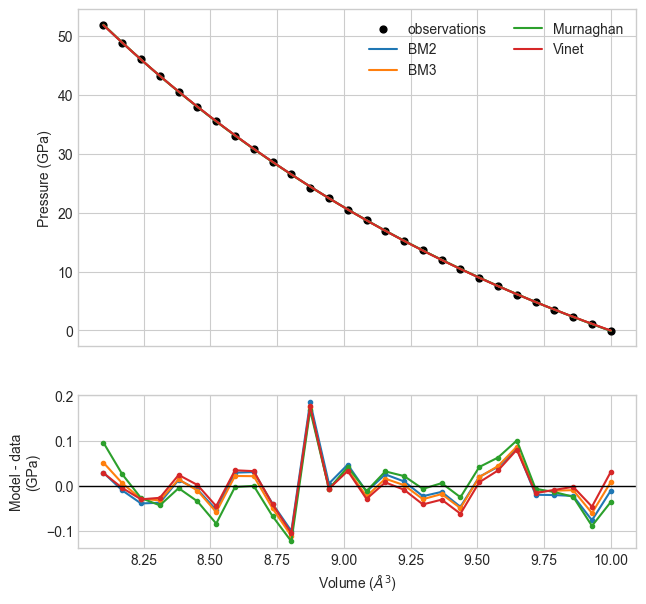

In [3]:
fit_grid = np.linspace(volumes.min(), volumes.max(), 300)
fig, (ax_curve, ax_residual) = plt.subplots(
    2, 1, figsize=(7.2, 7.0), sharex=True, height_ratios=(2.2, 1.0)
)

ax_curve.scatter(volumes, pressures, s=24, color="black", label="observations")
for name, result in results.items():
    ax_curve.plot(fit_grid, result.model.pressure(fit_grid), label=name)
    ax_residual.plot(
        volumes,
        result.model.pressure(volumes) - pressures,
        marker="o",
        ms=3,
        label=name,
    )

ax_curve.set(ylabel="Pressure (GPa)")
ax_curve.legend(ncol=2)
ax_residual.axhline(0.0, color="black", lw=1)
ax_residual.set(
    xlabel=r"Volume ($\AA^3$)",
    ylabel="Model - data\n(GPa)",
)
plt.show()

## Extrapolation separates apparently equivalent fits

Now extend the fitted curves to substantially greater compression. The shaded
region is the only interval constrained by observations. Divergence outside it
is a model assumption, not additional information learned from the fit.

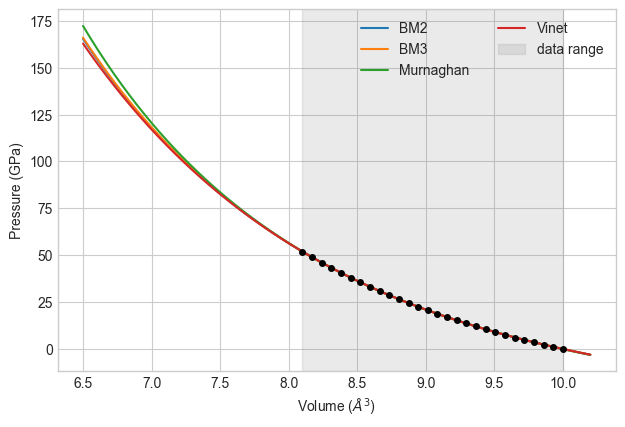

Predictions at V=6.5 A^3 (outside the data range):
  BM2          165.41 GPa
  BM3          166.02 GPa
  Murnaghan    172.29 GPa
  Vinet        162.88 GPa


In [4]:
extended_grid = np.linspace(6.5, 10.2, 400)
fig, ax = plt.subplots(figsize=(7.2, 4.7))
for name, result in results.items():
    ax.plot(extended_grid, result.model.pressure(extended_grid), label=name)

ax.axvspan(volumes.min(), volumes.max(), color="grey", alpha=0.16, label="data range")
ax.scatter(volumes, pressures, s=16, color="black", zorder=3)
ax.set(xlabel=r"Volume ($\AA^3$)", ylabel="Pressure (GPa)")
ax.legend(ncol=2)
plt.show()

probe_volume = 6.5
print(f"Predictions at V={probe_volume} A^3 (outside the data range):")
for name, result in results.items():
    print(f"  {name:10s} {result.model.pressure(probe_volume):8.2f} GPa")

## Inspect parameter correlation

The three-parameter fits usually couple $V_0$, $K_0$, and $K'_0$ strongly.
Large off-diagonal correlations explain why individually plausible parameter
values can shift while the predicted curve barely changes over the measured
interval.

In [5]:
for name in ("BM3", "Murnaghan", "Vinet"):
    result = results[name]
    print(f"{name} parameter order: {result.free_parameters}")
    print(np.array2string(result.correlation, precision=3, suppress_small=True))

BM3 parameter order: ('V0', 'K0', 'K0_prime')
[[ 1.    -0.885  0.732]
 [-0.885  1.    -0.956]
 [ 0.732 -0.956  1.   ]]
Murnaghan parameter order: ('V0', 'K0', 'K0_prime')
[[ 1.    -0.882  0.719]
 [-0.882  1.    -0.952]
 [ 0.719 -0.952  1.   ]]
Vinet parameter order: ('V0', 'K0', 'K0_prime')
[[ 1.    -0.887  0.746]
 [-0.887  1.    -0.961]
 [ 0.746 -0.961  1.   ]]


## Takeaways

1. Compare models using identical observations, residual definitions, and
   uncertainty assumptions.
2. AIC and BIC reward parsimony; they do not certify an equation's physics.
3. Report the fitted interval and treat extrapolation as a separate model
   choice.
4. Preserve covariance because EOS parameters are often strongly correlated.